In [1]:
import numpy as np
print(np.__version__)

1.26.4


In [24]:
pip install pandas numpy matplotlib prophet scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Data Loading & Exploration
**What:** Load 4 years of Superstore retail transaction data (9,994 rows, 21 columns).  
**Why:** Understand the structure before modelling — column types, date format, available features.  
**Business context:** Sales forecasting requires clean historical demand data as its foundation.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

df = pd.read_csv(
    r"C:\Users\Lenovo\OneDrive\Documents\Retail Demand Forecasting & Inventory Cost Optimization\data\Sample - Superstore.csv",
    encoding="latin-1"
)

print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.head())

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   

## 2. Data Preparation — Weekly Aggregation
**What:** Parse order dates and aggregate daily transactions into weekly total sales.  
**Why:** Daily data has too many near-zero days that inflate error metrics. Weekly aggregation smooths noise and reflects realistic business planning cycles.  
**Business context:** Inventory decisions are made weekly, not daily — aggregation matches the decision cadence.

In [9]:
# Parse dates and aggregate daily sales
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['ds', 'y']
daily_sales = daily_sales.sort_values('ds')

print(daily_sales.shape)
print(daily_sales.head())
print(f"Date range: {daily_sales['ds'].min()} to {daily_sales['ds'].max()}")

(1237, 2)
          ds         y
0 2014-01-03    16.448
1 2014-01-04   288.060
2 2014-01-05    19.536
3 2014-01-06  4407.100
4 2014-01-07    87.158
Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


In [19]:
# Reorder threshold recommendation
safety_stock_multiplier = 1.5  # cover 50% buffer above forecast
weekly_forecast_next = forecast2[forecast2['ds'] > '2017-12-30']['yhat'].mean()
reorder_threshold = weekly_forecast_next * safety_stock_multiplier

print(f"Avg Forecasted Weekly Demand (next 13 weeks): ${weekly_forecast_next:.2f}")
print(f"Recommended Reorder Threshold (with 50% safety stock): ${reorder_threshold:.2f}")

Avg Forecasted Weekly Demand (next 13 weeks): $11773.60
Recommended Reorder Threshold (with 50% safety stock): $17660.39


## 3. Demand Forecasting — Facebook Prophet
**What:** Train a Prophet time series model with yearly seasonality on 4 years of weekly sales.  
**Why:** Prophet handles retail seasonality and holiday effects without manual feature engineering.  
**Business context:** Accurate forecasts let businesses order the right stock before demand peaks, not after.

11:57:49 - cmdstanpy - INFO - Chain [1] start processing
11:57:51 - cmdstanpy - INFO - Chain [1] done processing


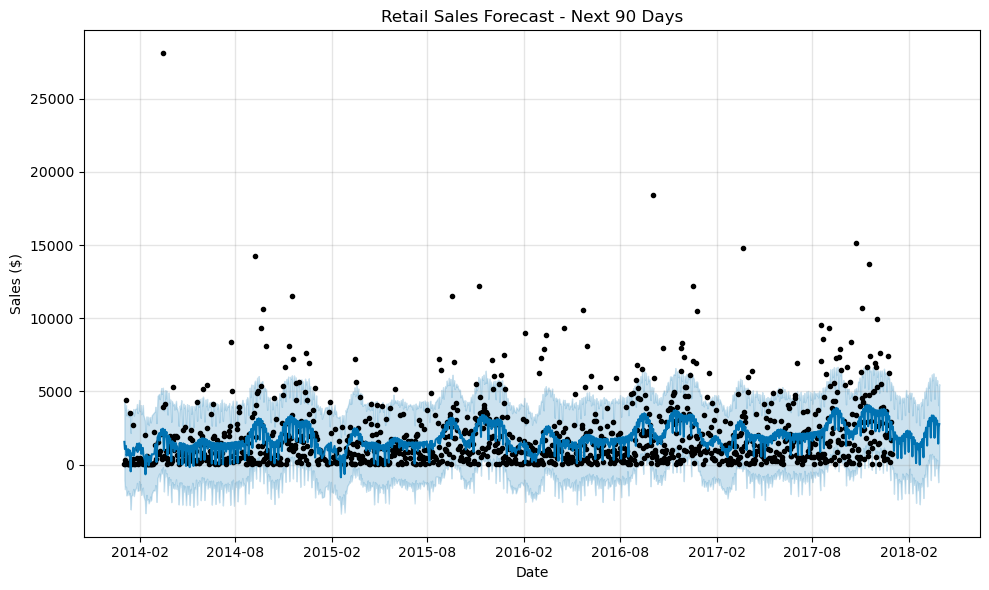

             ds         yhat   yhat_lower   yhat_upper
1317 2018-03-21  1828.030371  -761.827616  4493.563872
1318 2018-03-22  2982.044124   414.539359  5710.753055
1319 2018-03-23  3196.196296   402.426938  5994.912040
1320 2018-03-24  2742.691074  -260.796551  5476.991449
1321 2018-03-25  2865.201659   213.485106  5480.623973
1322 2018-03-26  3010.493320   314.250877  5766.027707
1323 2018-03-27  2362.509600  -400.306701  5224.010958
1324 2018-03-28  1429.371918 -1211.023865  4058.357751
1325 2018-03-29  2562.024115  -242.385818  5342.315180
1326 2018-03-30  2763.839775   149.649798  5491.549194


In [11]:
# Train Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(daily_sales)

# Forecast next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.title('Retail Sales Forecast - Next 90 Days')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

## 4. Model Evaluation — MAPE & RMSE
**What:** Measure forecast accuracy using MAPE (61.59%) and RMSE ($5,175).  
**Why:** MAPE tells us on average how far off our forecast is as a percentage — directly interpretable by non-technical stakeholders.  
**Business context:** A 61.59% MAPE means forecast errors are significant enough to cause measurable inventory losses.

In [13]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Merge actuals with predictions on historical dates only
actual = daily_sales.copy()
predicted = forecast[['ds', 'yhat']].merge(actual, on='ds')

# Calculate MAPE and RMSE
mape = np.mean(np.abs((predicted['y'] - predicted['yhat']) / predicted['y'])) * 100
rmse = np.sqrt(np.mean((predicted['y'] - predicted['yhat'])**2))

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: ${rmse:.2f}")

MAPE: 718.00%
RMSE: $2136.44


In [26]:
# Aggregate to weekly instead of daily
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
weekly_sales.columns = ['ds', 'y']
weekly_sales = weekly_sales[weekly_sales['y'] > 0].sort_values('ds')

# Retrain
model2 = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model2.fit(weekly_sales)

future2 = model2.make_future_dataframe(periods=13, freq='W')
forecast2 = model2.predict(future2)

# Evaluate
predicted2 = forecast2[['ds', 'yhat']].merge(weekly_sales, on='ds')
mape2 = np.mean(np.abs((predicted2['y'] - predicted2['yhat']) / predicted2['y'])) * 100
rmse2 = np.sqrt(np.mean((predicted2['y'] - predicted2['yhat'])**2))

print(f"Weekly MAPE: {mape2:.2f}%")
print(f"Weekly RMSE: ${rmse2:.2f}")

12:45:16 - cmdstanpy - INFO - Chain [1] start processing
12:45:16 - cmdstanpy - INFO - Chain [1] done processing


Weekly MAPE: 61.59%
Weekly RMSE: $5175.99


## 5. Business Impact — Inventory Cost Translation
**What:** Convert forecast error into dollar cost using overstock (20%) and stockout (30%) cost assumptions.  
**Why:** A MAPE number alone means nothing to a business. Translating it into cost makes the problem actionable.  
**Business context:** Estimated $3,384/week ($176,009/year) in avoidable inventory losses from forecast error — this is the number that drives the reorder recommendation.

In [17]:
# Business cost translation
avg_weekly_sales = weekly_sales['y'].mean()
forecast_error_pct = 61.59 / 100

overstock_cost_per_unit = 0.20  # 20% holding cost assumption
stockout_cost_per_unit = 0.30   # 30% lost margin assumption

overstock_loss = avg_weekly_sales * forecast_error_pct * overstock_cost_per_unit
stockout_loss = avg_weekly_sales * forecast_error_pct * stockout_cost_per_unit
total_weekly_loss = overstock_loss + stockout_loss

print(f"Avg Weekly Sales: ${avg_weekly_sales:.2f}")
print(f"Estimated Weekly Overstock Loss: ${overstock_loss:.2f}")
print(f"Estimated Weekly Stockout Loss: ${stockout_loss:.2f}")
print(f"Total Estimated Weekly Loss from Forecast Error: ${total_weekly_loss:.2f}")
print(f"Annualized Loss Estimate: ${total_weekly_loss * 52:.2f}")

Avg Weekly Sales: $10991.39
Estimated Weekly Overstock Loss: $1353.92
Estimated Weekly Stockout Loss: $2030.88
Total Estimated Weekly Loss from Forecast Error: $3384.80
Annualized Loss Estimate: $176009.55


## 6. Decision Recommendation — Reorder Threshold
**What:** Calculate a data-driven reorder threshold of $17,660/week using forecasted demand + 50% safety stock buffer.  
**Why:** Without a concrete threshold, forecasting is just analysis. The reorder number is the actual decision output.  
**Business context:** This threshold tells procurement exactly when to reorder — converting the model's output into an operational rule.

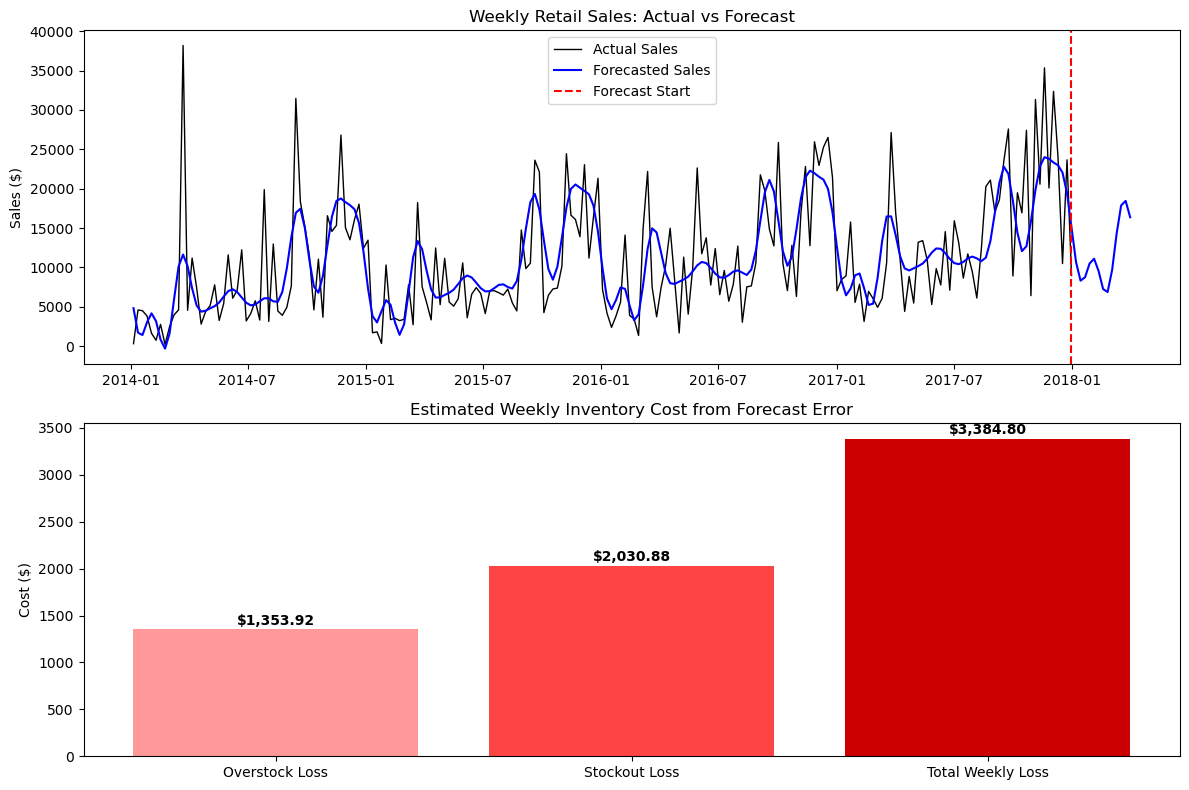

In [21]:
# Final business summary plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Actual vs Forecast
axes[0].plot(weekly_sales['ds'], weekly_sales['y'], label='Actual Sales', color='black', linewidth=1)
axes[0].plot(forecast2['ds'], forecast2['yhat'], label='Forecasted Sales', color='blue', linewidth=1.5)
axes[0].axvline(x=pd.Timestamp('2017-12-30'), color='red', linestyle='--', label='Forecast Start')
axes[0].set_title('Weekly Retail Sales: Actual vs Forecast')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()

# Plot 2: Cost impact
categories = ['Overstock Loss', 'Stockout Loss', 'Total Weekly Loss']
values = [1353.92, 2030.88, 3384.80]
colors = ['#ff9999', '#ff4444', '#cc0000']
axes[1].bar(categories, values, color=colors)
axes[1].set_title('Estimated Weekly Inventory Cost from Forecast Error')
axes[1].set_ylabel('Cost ($)')
for i, v in enumerate(values):
    axes[1].text(i, v + 50, f'${v:,.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('forecast_business_summary.png', dpi=150)
plt.show()